# YOI ↔ San Diego Workforce Partnership Youth Priorities Report Validation Notebook

This notebook validates the **Youth Opportunity Index (YOI)** county-region view against the San Diego Workforce Partnership / Working Current report: *Addressing the Priorities of Youth Across San Diego County: A Labor Market Analysis of Youth Populations & Services Across San Diego’s Four Major Regions*.

The validation is designed around the following report figures/data:

- **Figure 1, page 5:** education and employment outcomes across Metro, North, South, and East San Diego.
- **Figure 2, page 6:** youth population characteristics across the four regions.
- **Figure 10, page 15:** youth demographic snapshot and outcome table for all four regions.
- **Figure 22, page 27:** number of sites offering each education, employment, and wraparound service type, countywide and by region.
- **Figure 7, page 13:** report limitations; use these to interpret this validation directionally, not as exact truth.

The notebook produces:

1. a benchmark table with the exact values from the report,
2. direct dashboard-vs-report metric checks where the dashboard has matching columns,
3. service-site count checks against Figure 22,
4. YOI domain trend checks, especially `education_score`, `economic_score`, and `youth_supports_score`,
5. CSV outputs under `data/processed/validation/`, and
6. an auto-generated markdown summary.

**Important interpretation note:** the workforce report itself says findings should be interpreted as directional rather than exact because of age-range differences, proxy variables, PUMA/ZIP/school-district boundary mismatches, reporting gaps, timing mismatches, and service-data reliability limitations. This notebook therefore separates exact numeric checks from trend-alignment checks.

In [1]:
# Imports and display setup
from pathlib import Path
import json
import re
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

warnings.filterwarnings('ignore', category=FutureWarning)


## 1. Configuration

Run this notebook from the repository root if possible. If you run it elsewhere, set `REPO_ROOT` manually.

Expected files from your dashboard build:

- `data/processed/yoi/yoi_county_region_components.csv`
- `data/processed/overlays/service_locations.geojson`
- `data/rawdomains/regions/2020_Census_Tract_to_2020_PUMA.txt`

The notebook does not require the PDF to run because the report benchmark values are hard-coded below with source references.

In [2]:
# --- Path configuration ---

def find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / 'data').exists():
            return p
    return start

# Override this manually if needed, e.g.:
# REPO_ROOT = Path('/path/to/youth-opportunity-index')
REPO_ROOT = find_repo_root(Path.cwd())

REGION_YOI_CSV = REPO_ROOT / 'data/processed/yoi/yoi_county_region_components.csv'
TRACT_YOI_CSV = REPO_ROOT / 'data/processed/yoi/yoi_components.csv'
SERVICE_GEOJSON = REPO_ROOT / 'data/processed/overlays/service_locations.geojson'
PUMA_CROSSWALK = REPO_ROOT / 'data/rawdomains/regions/2020_Census_Tract_to_2020_PUMA.txt'

OUT_DIR = REPO_ROOT / 'data/processed/validation'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Numeric tolerances for direct report-vs-dashboard comparisons.
# Counts from ACS/service-provider data can legitimately differ if your source vintage/method differs.
COUNT_REL_TOL = 0.05      # 5% relative tolerance for demographic counts
RATE_ABS_TOL = 2.0        # 2 percentage points for rates
SERVICE_REL_TOL = 0.15    # 15% relative tolerance for service counts because dashboard service classification may be approximate

print('REPO_ROOT:', REPO_ROOT)
print('REGION_YOI_CSV exists:', REGION_YOI_CSV.exists(), REGION_YOI_CSV)
print('SERVICE_GEOJSON exists:', SERVICE_GEOJSON.exists(), SERVICE_GEOJSON)
print('PUMA_CROSSWALK exists:', PUMA_CROSSWALK.exists(), PUMA_CROSSWALK)


REPO_ROOT: /Users/laurenvo/Documents/Github/youth_opportunity_index
REGION_YOI_CSV exists: True /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/yoi/yoi_county_region_components.csv
SERVICE_GEOJSON exists: True /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/overlays/service_locations.geojson
PUMA_CROSSWALK exists: True /Users/laurenvo/Documents/Github/youth_opportunity_index/data/rawdomains/regions/2020_Census_Tract_to_2020_PUMA.txt


## 2. Region definitions used by the dashboard and the report

The report uses four major San Diego regions: **Metro San Diego**, **North County**, **South San Diego**, and **East San Diego**. This notebook uses the same PUMA-to-region mapping as your dashboard county-region build script.

In [3]:
REGION_ORDER = ['Metro San Diego', 'North County', 'South San Diego', 'East San Diego']

REGION_BY_PUMA = {
    # Metro San Diego
    '7308': 'Metro San Diego',
    '7310': 'Metro San Diego',
    '7311': 'Metro San Diego',
    '7312': 'Metro San Diego',
    '7315': 'Metro San Diego',
    '7316': 'Metro San Diego',
    '7317': 'Metro San Diego',
    '7327': 'Metro San Diego',

    # North County
    '7301': 'North County',
    '7306': 'North County',
    '7323': 'North County',
    '7324': 'North County',
    '7325': 'North County',
    '7326': 'North County',

    # South San Diego
    '7322': 'South San Diego',
    '7328': 'South San Diego',
    '7329': 'South San Diego',
    '7330': 'South San Diego',

    # East San Diego
    '7302': 'East San Diego',
    '7307': 'East San Diego',
    '7313': 'East San Diego',
    '7314': 'East San Diego',
}

EXCLUDED_TRACT_GEOIDS = {'06073990100'}  # ocean/water tract

def normalize_geoid(v):
    if pd.isna(v):
        return None
    digits = re.sub(r'\D', '', str(v))
    if not digits:
        return None
    if digits.startswith('06073') and len(digits) >= 11:
        return digits[:11]
    if len(digits) == 10:
        digits = digits.zfill(11)
        return digits if digits.startswith('06073') else None
    if len(digits) == 11:
        return digits if digits.startswith('06073') else None
    m = re.search(r'06073\d{6}', digits)
    if m:
        return m.group(0)
    return None

def normalize_region(v):
    if pd.isna(v):
        return None
    s = str(v).strip().lower()
    s = re.sub(r'[^a-z0-9]+', ' ', s).strip()
    aliases = {
        'metro': 'Metro San Diego',
        'metro san diego': 'Metro San Diego',
        'san diego metro region': 'Metro San Diego',
        'north': 'North County',
        'north county': 'North County',
        'south': 'South San Diego',
        'south san diego': 'South San Diego',
        'east': 'East San Diego',
        'east san diego': 'East San Diego',
        'east county': 'East San Diego',
    }
    return aliases.get(s, str(v).strip())

def read_tract_to_region_crosswalk(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Missing PUMA crosswalk: {path}')
    xwalk = pd.read_csv(path, dtype=str)
    required = {'STATEFP', 'COUNTYFP', 'TRACTCE', 'PUMA5CE'}
    missing = required - set(xwalk.columns)
    if missing:
        raise ValueError(f'Crosswalk missing columns: {missing}')

    xwalk['STATEFP'] = xwalk['STATEFP'].astype(str).str.zfill(2)
    xwalk['COUNTYFP'] = xwalk['COUNTYFP'].astype(str).str.zfill(3)
    xwalk['TRACTCE'] = xwalk['TRACTCE'].astype(str).str.zfill(6)
    xwalk = xwalk[(xwalk['STATEFP'] == '06') & (xwalk['COUNTYFP'] == '073')].copy()
    xwalk['tract_geoid'] = xwalk['STATEFP'] + xwalk['COUNTYFP'] + xwalk['TRACTCE']
    xwalk['puma_code'] = xwalk['PUMA5CE'].astype(str).str.replace(r'\D', '', regex=True).str.zfill(5).str[-4:]
    xwalk['county_region'] = xwalk['puma_code'].map(REGION_BY_PUMA)
    xwalk = xwalk[~xwalk['tract_geoid'].isin(EXCLUDED_TRACT_GEOIDS)].dropna(subset=['county_region']).copy()
    return xwalk[['tract_geoid', 'puma_code', 'county_region']].drop_duplicates()

if PUMA_CROSSWALK.exists():
    tract_region = read_tract_to_region_crosswalk(PUMA_CROSSWALK)
    display(tract_region.groupby(['county_region', 'puma_code']).size().rename('tract_count').reset_index())
else:
    tract_region = pd.DataFrame(columns=['tract_geoid', 'puma_code', 'county_region'])
    print('PUMA crosswalk not found yet. Service region assignment will be skipped until this file exists.')


,county_region,puma_code,tract_count
0,East San Diego,7302,28
1,East San Diego,7307,24
2,East San Diego,7313,43
3,East San Diego,7314,34
4,Metro San Diego,7308,30
5,Metro San Diego,7310,54
6,Metro San Diego,7311,25
7,Metro San Diego,7312,27
8,Metro San Diego,7315,34
9,Metro San Diego,7316,55


## 3. Hard-coded Workforce Report benchmark tables

These tables are the report values that the validation uses. Each row includes the exact figure/page reference so the output tables can cite what they validate against.

In [4]:
# Figure 10, page 15: Youth Demographic Snapshot: All Four Regions of San Diego.
# Source named in report: ACS 5-Year PUMS 2019-2023, ACS 1-Year Estimates 2024, and CDE DataQuest SY 2023-24.
FIG10_SOURCE = 'Workforce report Figure 10, p.15: Youth Demographic Snapshot: All Four Regions of San Diego'

fig10 = pd.DataFrame([
    {'county_region': 'Metro San Diego', 'population_ages_14_24': 180_692, 'population_ages_14_18': 66_428, 'population_ages_19_24': 94_976,
     'high_school_graduation_rate': 88.0, 'high_school_dropout_rate': 3.7, 'postsecondary_enrollment_number': 83_639,
     'postsecondary_enrollment_pct_ages_19_24': 63.0, 'credential_attainment_rate': 0.6, 'youth_unemployment_rate': 15.0,
     'labor_force_participation_rate': 35.0},
    {'county_region': 'North County', 'population_ages_14_24': 133_405, 'population_ages_14_18': 57_606, 'population_ages_19_24': 64_040,
     'high_school_graduation_rate': 87.0, 'high_school_dropout_rate': 8.7, 'postsecondary_enrollment_number': 44_099,
     'postsecondary_enrollment_pct_ages_19_24': 50.0, 'credential_attainment_rate': 0.3, 'youth_unemployment_rate': 9.0,
     'labor_force_participation_rate': 44.0},
    {'county_region': 'South San Diego', 'population_ages_14_24': 89_839, 'population_ages_14_18': 43_004, 'population_ages_19_24': 39_202,
     'high_school_graduation_rate': 82.0, 'high_school_dropout_rate': 8.7, 'postsecondary_enrollment_number': 30_685,
     'postsecondary_enrollment_pct_ages_19_24': 56.0, 'credential_attainment_rate': 0.2, 'youth_unemployment_rate': 31.0,
     'labor_force_participation_rate': 30.0},
    {'county_region': 'East San Diego', 'population_ages_14_24': 72_778, 'population_ages_14_18': 34_773, 'population_ages_19_24': 32_111,
     'high_school_graduation_rate': 81.0, 'high_school_dropout_rate': 11.6, 'postsecondary_enrollment_number': 22_634,
     'postsecondary_enrollment_pct_ages_19_24': 52.0, 'credential_attainment_rate': 0.3, 'youth_unemployment_rate': 18.0,
     'labor_force_participation_rate': 34.0},
])
fig10['source_reference'] = FIG10_SOURCE
fig10['county_region'] = pd.Categorical(fig10['county_region'], REGION_ORDER, ordered=True)
fig10 = fig10.sort_values('county_region').reset_index(drop=True)
display(fig10)


,county_region,population_ages_14_24,population_ages_14_18,population_ages_19_24,high_school_graduation_rate,high_school_dropout_rate,postsecondary_enrollment_number,postsecondary_enrollment_pct_ages_19_24,credential_attainment_rate,youth_unemployment_rate,labor_force_participation_rate,source_reference
0,Metro San Diego,180692,66428,94976,88.0,3.7,83639,63.0,0.6,15.0,35.0,"Workforce report Figure 10, p.15: Youth Demogr..."
1,North County,133405,57606,64040,87.0,8.7,44099,50.0,0.3,9.0,44.0,"Workforce report Figure 10, p.15: Youth Demogr..."
2,South San Diego,89839,43004,39202,82.0,8.7,30685,56.0,0.2,31.0,30.0,"Workforce report Figure 10, p.15: Youth Demogr..."
3,East San Diego,72778,34773,32111,81.0,11.6,22634,52.0,0.3,18.0,34.0,"Workforce report Figure 10, p.15: Youth Demogr..."


In [5]:
# Figure 2, page 6: Youth Population Characteristics Across San Diego's Four Regions.
FIG2_SOURCE = "Workforce report Figure 2, p.6: Youth Population Characteristics Across San Diego's Four Regions"

fig2 = pd.DataFrame([
    {'county_region': 'Metro San Diego', 'students_14_21': 125_358, 'not_in_school_18_24': 52_661, 'black_opportunity_youth': 2_851,
     'english_learners': 65_356, 'youth_low_income_households': 29_743, 'refugees': 1_118,
     'youth_experiencing_homelessness': 2_352, 'foster_youth_enrolled_in_school': 359},
    {'county_region': 'North County', 'students_14_21': 96_541, 'not_in_school_18_24': 50_738, 'black_opportunity_youth': 1_361,
     'english_learners': 41_621, 'youth_low_income_households': 9_875, 'refugees': 173,
     'youth_experiencing_homelessness': 468, 'foster_youth_enrolled_in_school': 181},
    {'county_region': 'South San Diego', 'students_14_21': 66_448, 'not_in_school_18_24': 25_481, 'black_opportunity_youth': 2_013,
     'english_learners': 49_100, 'youth_low_income_households': 9_432, 'refugees': 912,
     'youth_experiencing_homelessness': 134, 'foster_youth_enrolled_in_school': 97},
    {'county_region': 'East San Diego', 'students_14_21': 53_244, 'not_in_school_18_24': 20_457, 'black_opportunity_youth': 1_346,
     'english_learners': 19_454, 'youth_low_income_households': 10_318, 'refugees': 2_527,
     'youth_experiencing_homelessness': 1_056, 'foster_youth_enrolled_in_school': 216},
])
fig2['source_reference'] = FIG2_SOURCE
fig2['county_region'] = pd.Categorical(fig2['county_region'], REGION_ORDER, ordered=True)
fig2 = fig2.sort_values('county_region').reset_index(drop=True)
display(fig2)


,county_region,students_14_21,not_in_school_18_24,black_opportunity_youth,english_learners,youth_low_income_households,refugees,youth_experiencing_homelessness,foster_youth_enrolled_in_school,source_reference
0,Metro San Diego,125358,52661,2851,65356,29743,1118,2352,359,"Workforce report Figure 2, p.6: Youth Populati..."
1,North County,96541,50738,1361,41621,9875,173,468,181,"Workforce report Figure 2, p.6: Youth Populati..."
2,South San Diego,66448,25481,2013,49100,9432,912,134,97,"Workforce report Figure 2, p.6: Youth Populati..."
3,East San Diego,53244,20457,1346,19454,10318,2527,1056,216,"Workforce report Figure 2, p.6: Youth Populati..."


In [6]:
# Figure 22, page 27: Number of Sites Offering each Service Type, Countywide and per Region.
# Counts are number of sites offering each service type. A single physical site can be counted in multiple service types.
FIG22_SOURCE = 'Workforce report Figure 22, p.27: Number of Sites Offering each Service Type, Countywide and per Region'

fig22_rows = [
    # Education-related services
    ('Education-related services', 'Total - Education-Related Services', 8, 175, 72, 39, 42, 336),
    ('Education-related services', 'Tutoring and Dropout Prevention Services', 1, 87, 40, 14, 22, 164),
    ('Education-related services', 'Alternative Secondary School Services & Dropout Recovery', 2, 7, 8, 3, 2, 22),
    ('Education-related services', 'Post-Secondary Preparation', 2, 63, 17, 17, 13, 112),
    ('Education-related services', 'Educational Testing Assistance', 0, 17, 5, 4, 3, 29),
    ('Education-related services', 'Assistance with School Supplies and Fees', 3, 76, 36, 19, 21, 155),
    ('Education-related services', 'Leadership Development', 3, 115, 48, 27, 28, 221),

    # Employment-related services
    ('Employment-related services', 'Total - Employment-Related Services', 5, 154, 71, 35, 29, 294),
    ('Employment-related services', 'Work Experiences', 3, 76, 15, 19, 8, 121),
    ('Employment-related services', 'Occupational Skills Training', 4, 46, 6, 11, 11, 78),
    ('Employment-related services', 'General Workforce Preparation', 4, 129, 59, 27, 26, 245),
    ('Employment-related services', 'Integrated Education, Workforce Prep, & Occupational Skills', 0, 15, 0, 4, 4, 23),
    ('Employment-related services', 'Entrepreneurship Skills', 0, 34, 10, 7, 6, 57),
    ('Employment-related services', 'Financial Literacy', 3, 51, 24, 13, 11, 102),
    ('Employment-related services', 'Employment Follow Up (12+ mo.)', 0, 14, 0, 5, 0, 19),
    ('Employment-related services', 'Assistance with Work Attire or Tools', 0, 27, 6, 4, 2, 39),
    ('Employment-related services', 'Payments for Employment- and Training-Related Fees', 1, 17, 2, 4, 2, 26),
    ('Employment-related services', 'Reasonable Accommodations', 0, 10, 2, 3, 1, 16),

    # Wraparound services
    ('Wraparound services', 'Total - Wraparound Services', 10, 230, 99, 59, 61, 459),
    ('Wraparound services', 'Housing Assistance', 5, 67, 40, 12, 11, 135),
    ('Wraparound services', 'Drug/Alcohol and/or Mental Health Counseling', 6, 90, 49, 16, 23, 184),
    ('Wraparound services', 'Health Care for Youth', 4, 56, 29, 19, 12, 120),
    ('Wraparound services', 'Referrals to Community Services', 6, 59, 14, 11, 9, 99),
    ('Wraparound services', 'Transportation', 0, 42, 15, 5, 8, 70),
    ('Wraparound services', 'Child Care or Dependent Care', 0, 23, 8, 4, 9, 44),
    ('Wraparound services', 'Benefits Assistance', 0, 23, 4, 4, 3, 34),
    ('Wraparound services', 'Legal Aid', 0, 17, 9, 6, 3, 35),
    ('Wraparound services', 'Other Services', 8, 166, 72, 43, 44, 333),
]

fig22 = pd.DataFrame(fig22_rows, columns=['service_domain', 'service_type', 'unspecified_location', 'Metro San Diego', 'North County', 'South San Diego', 'East San Diego', 'san_diego_county_total'])
fig22['source_reference'] = FIG22_SOURCE

display(fig22.head(30))

fig22_totals = fig22[fig22['service_type'].str.startswith('Total -')].copy()
fig22_totals_long = fig22_totals.melt(
    id_vars=['service_domain', 'service_type', 'source_reference'],
    value_vars=REGION_ORDER,
    var_name='county_region',
    value_name='report_service_sites'
)
fig22_totals_long['county_region'] = pd.Categorical(fig22_totals_long['county_region'], REGION_ORDER, ordered=True)
fig22_totals_long = fig22_totals_long.sort_values(['service_domain', 'county_region']).reset_index(drop=True)

display(fig22_totals_long)


,service_domain,service_type,unspecified_location,Metro San Diego,North County,South San Diego,East San Diego,san_diego_county_total,source_reference
0,Education-related services,Total - Education-Related Services,8,175,72,39,42,336,"Workforce report Figure 22, p.27: Number of Si..."
1,Education-related services,Tutoring and Dropout Prevention Services,1,87,40,14,22,164,"Workforce report Figure 22, p.27: Number of Si..."
2,Education-related services,Alternative Secondary School Services & Dropou...,2,7,8,3,2,22,"Workforce report Figure 22, p.27: Number of Si..."
3,Education-related services,Post-Secondary Preparation,2,63,17,17,13,112,"Workforce report Figure 22, p.27: Number of Si..."
4,Education-related services,Educational Testing Assistance,0,17,5,4,3,29,"Workforce report Figure 22, p.27: Number of Si..."
5,Education-related services,Assistance with School Supplies and Fees,3,76,36,19,21,155,"Workforce report Figure 22, p.27: Number of Si..."
6,Education-related services,Leadership Development,3,115,48,27,28,221,"Workforce report Figure 22, p.27: Number of Si..."
7,Employment-related services,Total - Employment-Related Services,5,154,71,35,29,294,"Workforce report Figure 22, p.27: Number of Si..."
8,Employment-related services,Work Experiences,3,76,15,19,8,121,"Workforce report Figure 22, p.27: Number of Si..."
9,Employment-related services,Occupational Skills Training,4,46,6,11,11,78,"Workforce report Figure 22, p.27: Number of Si..."


,service_domain,service_type,source_reference,county_region,report_service_sites
0,Education-related services,Total - Education-Related Services,"Workforce report Figure 22, p.27: Number of Si...",Metro San Diego,175
1,Education-related services,Total - Education-Related Services,"Workforce report Figure 22, p.27: Number of Si...",North County,72
2,Education-related services,Total - Education-Related Services,"Workforce report Figure 22, p.27: Number of Si...",South San Diego,39
3,Education-related services,Total - Education-Related Services,"Workforce report Figure 22, p.27: Number of Si...",East San Diego,42
4,Employment-related services,Total - Employment-Related Services,"Workforce report Figure 22, p.27: Number of Si...",Metro San Diego,154
5,Employment-related services,Total - Employment-Related Services,"Workforce report Figure 22, p.27: Number of Si...",North County,71
6,Employment-related services,Total - Employment-Related Services,"Workforce report Figure 22, p.27: Number of Si...",South San Diego,35
7,Employment-related services,Total - Employment-Related Services,"Workforce report Figure 22, p.27: Number of Si...",East San Diego,29
8,Wraparound services,Total - Wraparound Services,"Workforce report Figure 22, p.27: Number of Si...",Metro San Diego,230
9,Wraparound services,Total - Wraparound Services,"Workforce report Figure 22, p.27: Number of Si...",North County,99


## 4. Load dashboard region data

This loads `yoi_county_region_components.csv`, which should already be aggregated to the same four regions. The notebook expects at minimum a `county_region` column. YOI domain columns like `education_score`, `economic_score`, and `youth_supports_score` are used for trend tests when present.

In [7]:
def load_region_yoi(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f'Missing {path}. Run build_yoi_county_region_components.py first or update REGION_YOI_CSV.')
        return pd.DataFrame()
    df = pd.read_csv(path)
    if 'county_region' not in df.columns:
        # Try common aliases.
        for c in df.columns:
            if c.lower() in {'region', 'county_region_name', 'region_name'}:
                df = df.rename(columns={c: 'county_region'})
                break
    if 'county_region' not in df.columns:
        raise ValueError('Region YOI file must contain county_region or a recognizable region name column.')
    df['county_region'] = df['county_region'].map(normalize_region)
    df = df[df['county_region'].isin(REGION_ORDER)].copy()
    df['county_region'] = pd.Categorical(df['county_region'], REGION_ORDER, ordered=True)
    return df.sort_values('county_region').reset_index(drop=True)

yoi_region = load_region_yoi(REGION_YOI_CSV)
print('YOI region rows:', len(yoi_region))
display(yoi_region.head())

missing_regions = sorted(set(REGION_ORDER) - set(yoi_region['county_region'].astype(str))) if len(yoi_region) else REGION_ORDER
if missing_regions:
    print('Missing dashboard regions:', missing_regions)
else:
    print('All four report regions are present in your dashboard region file.')


YOI region rows: 4


,county_region_id,county_region,tract_count,puma_codes,total_population,economic_score,economic_coverage,education_score,education_coverage,health_score,health_coverage,housing_score,housing_coverage,safety_env_score,safety_env_coverage,mobility_connectivity_score,mobility_connectivity_coverage,youth_supports_score,youth_supports_coverage,yoi_domain_coverage,yoi_raw_0_1,yoi_0_100,poverty_rate,median_hh_income,unemployment_rate,snap_or_assist_rate,hs_plus,ba_plus,school_enrollment,youth_disconnection_proxy,uninsured_rate,disability_rate,frequent_mental_distress,poor_physical_health,rent_burden_proxy,overcrowding_proxy,moved_past_year_proxy,homeownership_rate,single_parent_proxy,vacancy_rate,crime_rate_per_1k,env_burden,no_vehicle_rate,commute_time_proxy,internet_sub_rate_proxy,school_access,college_university_access,tier_weighted_youth_program_access,youth_development_access,barrier_reduction_access,transition_pathway_access,segment_specific_support_access,norm_poverty_rate,norm_median_hh_income,norm_unemployment_rate,norm_snap_or_assist_rate,norm_hs_plus,norm_ba_plus,norm_school_enrollment,norm_youth_disconnection_proxy,norm_uninsured_rate,norm_disability_rate,norm_frequent_mental_distress,norm_poor_physical_health,norm_rent_burden_proxy,norm_overcrowding_proxy,norm_moved_past_year_proxy,norm_homeownership_rate,norm_single_parent_proxy,norm_vacancy_rate,norm_crime_rate_per_1k,norm_env_burden,norm_no_vehicle_rate,norm_commute_time_proxy,norm_internet_sub_rate_proxy,norm_school_access,norm_college_university_access,norm_tier_weighted_youth_program_access,norm_youth_development_access,norm_barrier_reduction_access,norm_transition_pathway_access,norm_segment_specific_support_access,service_count,basic_navigation_access,lack_transport,school_count_nearby,college_university_count_nearby,yoi_custom_0_1,yoi_custom_0_100
0,metro_san_diego,Metro San Diego,293,"7308, 7310, 7311, 7312, 7315, 7316, 7317, 7327",1204190,0.503062,0.993258,0.589063,0.994498,0.525934,1.0,0.472275,0.998441,0.481081,0.947285,0.554646,0.998856,0.624111,1.0,1.000000,0.535739,53.573871,518.023452,115542.372286,5.879303,5.758739,51.982587,466.639872,80.171488,5.131577,4296.810509,472.925484,16.455364,11.122735,54.322191,5.932486,15.851971,47.786866,26.980391,6.665945,31.302369,39.898317,6.982180,27.957795,94.966957,19.426239,22.949660,127.087929,60.793683,57.254473,81.740841,19.879828,0.459892,0.505820,0.507688,0.532392,0.615115,0.612798,0.444838,0.527914,0.447977,0.508103,0.521821,0.625835,0.534503,0.534734,0.409780,0.412610,0.495647,0.472146,0.492090,0.470731,0.440269,0.697285,0.524723,0.603194,0.728376,0.624924,0.629589,0.623345,0.626840,0.615855,136.760980,12.918918,8.572060,33.853589,53.325334,0.535739,53.573871
1,north_county,North County,185,"7301, 7306, 7323, 7324, 7325, 7326",880754,0.514075,0.997989,0.428736,1.000000,0.453227,1.0,0.496223,1.000000,0.533502,0.910149,0.505159,1.000000,0.305874,1.0,1.000000,0.462400,46.239963,496.664777,120092.025281,5.352154,6.002868,43.966761,544.256158,84.448217,4.541720,5210.456621,532.734397,16.590226,12.018156,59.281224,6.473323,12.409354,59.205638,23.627041,5.177152,27.569560,37.150540,3.911932,40.499299,95.920231,10.514968,9.851458,31.265515,14.971421,14.443514,15.235513,4.519966,0.463282,0.537925,0.549123,0.504131,0.509398,0.520920,0.526976,0.486609,0.364546,0.436131,0.506985,0.505244,0.435373,0.508565,0.498361,0.542595,0.537351,0.538013,0.531502,0.503743,0.577094,0.381634,0.556751,0.339227,0.189290,0.306648,0.300706,0.305660,0.305868,0.310488,37.789957,2.634818,8.386552,18.312151,24.843609,0.462400,46.239963
2,south_san_diego,South San Diego,129,"7322, 7328, 7329, 7330",617790,0.389575,0.996152,0.507888,1.000000,0.388688,1.0,0.480259,0.996152,0.484616,0.937223,0.416444,0.994869,0.554517,1.0,0.999267,0.460298,46.028383,526.759446,103638.986990,7.868489,9.129875,28.383472,422.701405,87.442103,5.480478,4975.141202,603.076377,16.642592,13.277291,58.534548,10.656159,8.614928,57.832549,29.475707,4.916345,27.323200,41.69607

All four report regions are present in your dashboard region file.


## 5. Direct numeric validation against Figure 10 and Figure 2

This section compares exact report metrics to dashboard columns **only when matching columns exist**. If your regional YOI file does not contain report-style youth demographic columns, the notebook will return `missing_dashboard_column` for those metrics and still keep the report benchmark table for your validation report.

To enable direct checks, add or point to a regional metrics CSV with columns such as:

- `population_ages_14_24`
- `students_14_21`
- `not_in_school_18_24`
- `high_school_graduation_rate`
- `high_school_dropout_rate`
- `youth_unemployment_rate`
- `labor_force_participation_rate`

The YOI domain trend tests later do not require these exact columns.

In [8]:
def canonical_col(s):
    return re.sub(r'[^a-z0-9]+', '_', str(s).strip().lower()).strip('_')

COLUMN_ALIASES = {
    # Figure 10 metrics
    'population_ages_14_24': ['population_ages_14_24', 'youth_population_14_24', 'total_youth_population_14_24', 'youth_pop_14_24'],
    'population_ages_14_18': ['population_ages_14_18', 'youth_population_14_18', 'youth_pop_14_18'],
    'population_ages_19_24': ['population_ages_19_24', 'youth_population_19_24', 'youth_pop_19_24'],
    'high_school_graduation_rate': ['high_school_graduation_rate', 'hs_graduation_rate', 'graduation_rate', 'high_school_grad_rate'],
    'high_school_dropout_rate': ['high_school_dropout_rate', 'hs_dropout_rate', 'dropout_rate'],
    'postsecondary_enrollment_number': ['postsecondary_enrollment_number', 'postsecondary_enrollment', 'college_enrollment_18_24'],
    'postsecondary_enrollment_pct_ages_19_24': ['postsecondary_enrollment_pct_ages_19_24', 'postsecondary_enrollment_pct', 'college_enrollment_rate_19_24'],
    'credential_attainment_rate': ['credential_attainment_rate', 'credential_attainment', 'college_career_readiness_rate'],
    'youth_unemployment_rate': ['youth_unemployment_rate', 'unemployment_rate_youth', 'unemployment_rate'],
    'labor_force_participation_rate': ['labor_force_participation_rate', 'lfpr', 'youth_labor_force_participation_rate'],

    # Figure 2 metrics
    'students_14_21': ['students_14_21', 'youth_enrolled_school_14_21', 'students', 'in_school_youth'],
    'not_in_school_18_24': ['not_in_school_18_24', 'youth_not_enrolled_school_18_24', 'not_in_school', 'out_of_school_youth'],
    'black_opportunity_youth': ['black_opportunity_youth', 'black_youth', 'black_opportunity'],
    'english_learners': ['english_learners', 'ell', 'english_language_learners'],
    'youth_low_income_households': ['youth_low_income_households', 'low_income_youth', 'youth_in_low_income_households'],
    'refugees': ['refugees', 'refugee_youth'],
    'youth_experiencing_homelessness': ['youth_experiencing_homelessness', 'homeless_youth', 'unhoused_youth'],
    'foster_youth_enrolled_in_school': ['foster_youth_enrolled_in_school', 'foster_youth', 'foster_students'],
}

def find_matching_col(df: pd.DataFrame, metric: str):
    if df is None or len(df.columns) == 0:
        return None
    canon_to_original = {canonical_col(c): c for c in df.columns}
    for alias in COLUMN_ALIASES.get(metric, [metric]):
        hit = canon_to_original.get(canonical_col(alias))
        if hit is not None:
            return hit
    return None

def metric_kind(metric: str) -> str:
    if metric.endswith('_rate') or metric.endswith('_pct_ages_19_24'):
        return 'rate_pct'
    return 'count'

def compare_report_to_dashboard(report_df: pd.DataFrame, dashboard_df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    rows = []
    metrics = [c for c in report_df.columns if c not in {'county_region', 'source_reference'}]
    for metric in metrics:
        dash_col = find_matching_col(dashboard_df, metric)
        for _, r in report_df.iterrows():
            region = str(r['county_region'])
            report_value = pd.to_numeric(r[metric], errors='coerce')
            row = {
                'source_table': source_name,
                'source_reference': r.get('source_reference'),
                'county_region': region,
                'metric': metric,
                'report_value': report_value,
                'dashboard_column': dash_col,
            }
            if dash_col is None or dashboard_df.empty:
                row.update({'dashboard_value': np.nan, 'abs_diff': np.nan, 'pct_diff': np.nan, 'status': 'missing_dashboard_column'})
            else:
                match = dashboard_df[dashboard_df['county_region'].astype(str) == region]
                if match.empty:
                    row.update({'dashboard_value': np.nan, 'abs_diff': np.nan, 'pct_diff': np.nan, 'status': 'missing_region_in_dashboard'})
                else:
                    dashboard_value = pd.to_numeric(match.iloc[0][dash_col], errors='coerce')
                    abs_diff = dashboard_value - report_value
                    pct_diff = (abs_diff / report_value * 100) if pd.notna(report_value) and report_value != 0 else np.nan
                    kind = metric_kind(metric)
                    if pd.isna(dashboard_value):
                        status = 'dashboard_value_not_numeric'
                    elif kind == 'rate_pct':
                        status = 'pass' if abs(abs_diff) <= RATE_ABS_TOL else 'review'
                    else:
                        status = 'pass' if (pd.notna(pct_diff) and abs(pct_diff) <= COUNT_REL_TOL * 100) else 'review'
                    row.update({'dashboard_value': dashboard_value, 'abs_diff': abs_diff, 'pct_diff': pct_diff, 'status': status})
            rows.append(row)
    return pd.DataFrame(rows)

fig10_compare = compare_report_to_dashboard(fig10, yoi_region, 'Figure 10')
fig2_compare = compare_report_to_dashboard(fig2, yoi_region, 'Figure 2')
metric_validation = pd.concat([fig10_compare, fig2_compare], ignore_index=True)
metric_validation.to_csv(OUT_DIR / 'workforce_report_metric_level_validation.csv', index=False)

print('Saved:', OUT_DIR / 'workforce_report_metric_level_validation.csv')
display(metric_validation.head(50))
print(metric_validation['status'].value_counts(dropna=False))


Saved: /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/validation/workforce_report_metric_level_validation.csv


,source_table,source_reference,county_region,metric,report_value,dashboard_column,dashboard_value,abs_diff,pct_diff,status
0,Figure 10,"Workforce report Figure 10, p.15: Youth Demogr...",Metro San Diego,population_ages_14_24,180692.0,None,NaN,NaN,NaN,missing_dashboard_column
1,Figure 10,"Workforce report Figure 10, p.15: Youth Demogr...",North County,population_ages_14_24,133405.0,None,NaN,NaN,NaN,missing_dashboard_column
2,Figure 10,"Workforce report Figure 10, p.15: Youth Demogr...",South San Diego,population_ages_14_24,89839.0,None,NaN,NaN,NaN,missing_dashboard_column
3,Figure 10,"Workforce report Figure 10, p.15: Youth Demogr...",East San Diego,population_ages_14_24,72778.0,None,NaN,NaN,NaN,missing_dashboard_column
4,Figure 10,"Workforce report Figure 10, p.15: Youth Demogr...",Metro San Diego,population_ages_14_18,66428.0,None,NaN,NaN,NaN,missing_dashboard_column
5,Figure 10,"Workforce report Figure 10, p.15: Youth Demogr...",North County,population_ages_14_18,57606.0,None,NaN,NaN,NaN,missing_dashboard_column
6,Figure 10,"Workforce report Figure 10, p.15: Youth Demogr...",South San Diego,population_ages_14_18,43004.0,None,NaN,NaN,NaN,missing_dashboard_column
7,Figure 10,"Workforce report Figure 10, p.15: Youth Demogr...",East San Diego,population_ages_14_18,34773.0,None,NaN,NaN,NaN,missing_dashboard_column
8,Figure 10,"Workforce report Figure 10, p.15: Youth Demogr...",Metro San Diego,population_ages_19_24,94976.0,None,NaN,NaN,NaN,missing_dashboard_column
9,Figure 10,"Workforce report Figure 10, p.15: Youth Demogr...",North County,population_ages_19_24,64040.0,None,NaN,NaN,NaN,missing_dashboard_column


status
missing_dashboard_column    68
review                       4
Name: count, dtype: int64


## 6. Service-site validation against Figure 22

This section checks whether your dashboard service layer shows the same broad pattern as Figure 22:

- Metro has the largest concentration of service sites across education, employment, and wraparound services.
- South and East are relatively thinner in service coverage.
- North is generally between Metro and South/East.

Because the dashboard service layer may not preserve the same service taxonomy as the Workforce report, this notebook uses a transparent keyword audit. It exports `service_category_audit.csv` so you can inspect which rows were classified as education, employment, and wraparound.

If your service file has official boolean/category columns, modify `classify_service_domains()` to use those first.

In [9]:
def read_geojson_properties(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f'Missing service GeoJSON: {path}')
        return pd.DataFrame()
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for i, feat in enumerate(data.get('features', [])):
        props = feat.get('properties') or {}
        props['_feature_index'] = i
        rows.append(props)
    return pd.DataFrame(rows)

def make_site_key(df: pd.DataFrame) -> pd.Series:
    preferred = ['provider_name', 'site_name', 'name', 'address', 'city', 'zip', 'lat', 'lon', 'tract_geoid']
    cols = [c for c in preferred if c in df.columns]
    if not cols:
        return pd.Series(df.index.astype(str), index=df.index)
    key = df[cols].fillna('').astype(str).agg('|'.join, axis=1)
    blank = key.str.replace('|', '', regex=False).str.strip().eq('')
    key.loc[blank] = df.index[blank].astype(str)
    return key

def text_blob(df: pd.DataFrame) -> pd.Series:
    cols = [c for c in ['programs', 'type', 'name', 'provider_name', 'site_name'] if c in df.columns]
    if not cols:
        return pd.Series('', index=df.index)
    return df[cols].fillna('').astype(str).agg(' '.join, axis=1).str.lower()

def classify_service_domains(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    t = text_blob(df)

    # These regexes are intentionally broad. The audit CSV lets you inspect false positives/negatives.
    education_re = re.compile(
        r'tutor|tutoring|study skills|instruction|dropout|dropout prevention|dropout recovery|alternative secondary|\bschool\b|academic|college|postsecondary|post-secondary|college prep|educational testing|testing assistance|school supplies|books|fees|scholarship|leadership',
        flags=re.I
    )
    employment_re = re.compile(
        r'employment|workforce|\bjob\b|career|career readiness|work readiness|internship|work experience|paid work|unpaid work|occupational|skills training|job training|workforce preparation|labor market|entrepreneurship|financial literacy|work attire|uniform|tools|employment fees|training fees|reasonable accommodations|apprentice',
        flags=re.I
    )
    wraparound_re = re.compile(
        r'housing|shelter|mental health|counseling|drug|alcohol|health care|healthcare|referral|community services|transportation|child care|childcare|dependent care|benefits|needs-related|legal|legal aid|case management|food|basic needs|family services|family support|parenting|pregnancy|mentoring|mentor|life skills|arts|sports|recreation|enrichment|youth development|civic engagement|cultural|creative youth development|navigation|resource',
        flags=re.I
    )

    # Use your dashboard's youth-support flag when present as a supplemental diagnostic, not as the Figure 22 benchmark.
    df['dashboard_education_related_service'] = t.str.contains(education_re, na=False).astype(int)
    df['dashboard_employment_related_service'] = t.str.contains(employment_re, na=False).astype(int)
    df['dashboard_wraparound_service'] = t.str.contains(wraparound_re, na=False).astype(int)

    if 'count_in_youth_supports' in df.columns:
        df['dashboard_youth_supports_flag'] = pd.to_numeric(df['count_in_youth_supports'], errors='coerce').fillna(0).gt(0).astype(int)
    else:
        df['dashboard_youth_supports_flag'] = df['dashboard_wraparound_service']

    return df

def assign_service_regions(services: pd.DataFrame, tract_region: pd.DataFrame) -> pd.DataFrame:
    services = services.copy()
    if services.empty:
        return services
    if 'county_region' in services.columns:
        services['county_region'] = services['county_region'].map(normalize_region)
    else:
        services['county_region'] = None
    if services['county_region'].isna().any() and 'tract_geoid' in services.columns and not tract_region.empty:
        services['tract_geoid'] = services['tract_geoid'].apply(normalize_geoid)
        services = services.merge(tract_region[['tract_geoid', 'county_region']].rename(columns={'county_region': '_region_from_tract'}), on='tract_geoid', how='left')
        services['county_region'] = services['county_region'].fillna(services['_region_from_tract'])
        services = services.drop(columns=['_region_from_tract'])
    services = services[services['county_region'].isin(REGION_ORDER)].copy()
    services['county_region'] = pd.Categorical(services['county_region'], REGION_ORDER, ordered=True)
    return services

services = read_geojson_properties(SERVICE_GEOJSON)
print('Raw service rows:', len(services))

if not services.empty:
    services = assign_service_regions(services, tract_region)
    services['_site_key'] = make_site_key(services)
    services = classify_service_domains(services)

    audit_cols = [c for c in [
        'county_region', '_site_key', 'service_id', 'provider_name', 'site_name', 'name', 'type', 'programs',
        'dashboard_education_related_service', 'dashboard_employment_related_service', 'dashboard_wraparound_service', 'dashboard_youth_supports_flag'
    ] if c in services.columns]
    services[audit_cols].to_csv(OUT_DIR / 'service_category_audit.csv', index=False)
    print('Saved:', OUT_DIR / 'service_category_audit.csv')

    # Collapse to unique site within each region; one site can count in multiple broad categories.
    site_flags = (
        services
        .groupby(['county_region', '_site_key'], observed=True)[[
            'dashboard_education_related_service',
            'dashboard_employment_related_service',
            'dashboard_wraparound_service',
            'dashboard_youth_supports_flag'
        ]]
        .max()
        .reset_index()
    )

    dashboard_service_counts = (
        site_flags
        .groupby('county_region', observed=True)[[
            'dashboard_education_related_service',
            'dashboard_employment_related_service',
            'dashboard_wraparound_service',
            'dashboard_youth_supports_flag'
        ]]
        .sum()
        .reset_index()
    )

    dashboard_unique_sites = site_flags.groupby('county_region', observed=True)['_site_key'].nunique().reset_index(name='dashboard_unique_service_sites')
    dashboard_service_counts = dashboard_service_counts.merge(dashboard_unique_sites, on='county_region', how='left')
    dashboard_service_counts['county_region'] = pd.Categorical(dashboard_service_counts['county_region'], REGION_ORDER, ordered=True)
    dashboard_service_counts = dashboard_service_counts.sort_values('county_region').reset_index(drop=True)
else:
    dashboard_service_counts = pd.DataFrame(columns=['county_region'])

print('Dashboard service counts by region:')
display(dashboard_service_counts)


Raw service rows: 362
Saved: /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/validation/service_category_audit.csv
Dashboard service counts by region:


,county_region,dashboard_education_related_service,dashboard_employment_related_service,dashboard_wraparound_service,dashboard_youth_supports_flag,dashboard_unique_service_sites
0,Metro San Diego,76,91,143,173,195
1,North County,28,24,67,68,77
2,South San Diego,11,11,36,35,41
3,East San Diego,23,5,40,43,49


In [10]:
# Compare broad service domains to Figure 22 totals.
SERVICE_DOMAIN_TO_DASH_COL = {
    'Education-related services': 'dashboard_education_related_service',
    'Employment-related services': 'dashboard_employment_related_service',
    'Wraparound services': 'dashboard_wraparound_service',
}

service_compare_rows = []
for _, r in fig22_totals_long.iterrows():
    region = str(r['county_region'])
    domain = r['service_domain']
    dash_col = SERVICE_DOMAIN_TO_DASH_COL.get(domain)
    report_value = pd.to_numeric(r['report_service_sites'], errors='coerce')
    row = {
        'source_reference': r['source_reference'],
        'county_region': region,
        'service_domain': domain,
        'report_service_sites': report_value,
        'dashboard_column': dash_col,
    }
    if dashboard_service_counts.empty or dash_col not in dashboard_service_counts.columns:
        row.update({'dashboard_service_sites': np.nan, 'abs_diff': np.nan, 'pct_diff': np.nan, 'status': 'missing_dashboard_service_data'})
    else:
        match = dashboard_service_counts[dashboard_service_counts['county_region'].astype(str) == region]
        if match.empty:
            row.update({'dashboard_service_sites': np.nan, 'abs_diff': np.nan, 'pct_diff': np.nan, 'status': 'missing_region_in_dashboard'})
        else:
            dash_value = pd.to_numeric(match.iloc[0][dash_col], errors='coerce')
            abs_diff = dash_value - report_value
            pct_diff = abs_diff / report_value * 100 if pd.notna(report_value) and report_value != 0 else np.nan
            status = 'pass' if pd.notna(pct_diff) and abs(pct_diff) <= SERVICE_REL_TOL * 100 else 'review'
            row.update({'dashboard_service_sites': dash_value, 'abs_diff': abs_diff, 'pct_diff': pct_diff, 'status': status})
    service_compare_rows.append(row)

service_validation = pd.DataFrame(service_compare_rows)
service_validation.to_csv(OUT_DIR / 'workforce_report_service_validation.csv', index=False)
print('Saved:', OUT_DIR / 'workforce_report_service_validation.csv')
display(service_validation)
print(service_validation['status'].value_counts(dropna=False))


Saved: /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/validation/workforce_report_service_validation.csv


,source_reference,county_region,service_domain,report_service_sites,dashboard_column,dashboard_service_sites,abs_diff,pct_diff,status
0,"Workforce report Figure 22, p.27: Number of Si...",Metro San Diego,Education-related services,175,dashboard_education_related_service,76,-99,-56.571429,review
1,"Workforce report Figure 22, p.27: Number of Si...",North County,Education-related services,72,dashboard_education_related_service,28,-44,-61.111111,review
2,"Workforce report Figure 22, p.27: Number of Si...",South San Diego,Education-related services,39,dashboard_education_related_service,11,-28,-71.794872,review
3,"Workforce report Figure 22, p.27: Number of Si...",East San Diego,Education-related services,42,dashboard_education_related_service,23,-19,-45.238095,review
4,"Workforce report Figure 22, p.27: Number of Si...",Metro San Diego,Employment-related services,154,dashboard_employment_related_service,91,-63,-40.909091,review
5,"Workforce report Figure 22, p.27: Number of Si...",North County,Employment-related services,71,dashboard_employment_related_service,24,-47,-66.197183,review
6,"Workforce report Figure 22, p.27: Number of Si...",South San Diego,Employment-related services,35,dashboard_employment_related_service,11,-24,-68.571429,review
7,"Workforce report Figure 22, p.27: Number of Si...",East San Diego,Employment-related services,29,dashboard_employment_related_service,5,-24,-82.758621,review
8,"Workforce report Figure 22, p.27: Number of Si...",Metro San Diego,Wraparound services,230,dashboard_wraparound_service,143,-87,-37.826087,review
9,"Workforce report Figure 22, p.27: Number of Si...",North County,Wraparound services,99,dashboard_wraparound_service,67,-32,-32.323232,review


status
review    12
Name: count, dtype: int64


## 7. YOI domain trend tests against Figure 10 and Figure 22

These tests validate whether the **direction** of your YOI scores aligns with report findings:

- `education_score` should generally be higher where graduation is higher and dropout is lower.
- `economic_score` should generally be higher where unemployment is lower and labor-force participation is higher.
- `youth_supports_score` should be interpreted carefully. It can be compared against Figure 22 wraparound-service coverage, but service supply may be high either because a region has more opportunity infrastructure or because a region has greater need.

With only four regions, Spearman correlations are directional diagnostics, not formal statistical proof.

In [11]:
def spearman_rho(x, y):
    s = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(s) < 3:
        return np.nan
    return s['x'].rank().corr(s['y'].rank())

def zscore(s):
    s = pd.to_numeric(s, errors='coerce')
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return s * 0
    return (s - s.mean()) / sd

# Base table for trend diagnostics.
trend_base = fig10.drop(columns=['source_reference']).merge(
    fig22_totals_long[fig22_totals_long['service_domain'] == 'Wraparound services'][['county_region', 'report_service_sites']]
        .rename(columns={'report_service_sites': 'report_wraparound_service_sites'}),
    on='county_region', how='left'
)
trend_base['report_wraparound_sites_per_10k_youth'] = trend_base['report_wraparound_service_sites'] / trend_base['population_ages_14_24'] * 10_000

# A simple distress composite: high dropout + high unemployment - graduation - LFPR.
trend_base['report_distress_composite'] = (
    zscore(trend_base['high_school_dropout_rate']) +
    zscore(trend_base['youth_unemployment_rate']) -
    zscore(trend_base['high_school_graduation_rate']) -
    zscore(trend_base['labor_force_participation_rate'])
)

if not yoi_region.empty:
    trend = yoi_region.merge(trend_base, on='county_region', how='left')
else:
    trend = trend_base.copy()

display(trend)

trend_tests = [
    {
        'test_name': 'Education score vs high school graduation rate',
        'dashboard_score_col': 'education_score',
        'report_metric_col': 'high_school_graduation_rate',
        'expected_direction': 'positive',
        'source_reference': FIG10_SOURCE,
        'interpretation': 'Higher education opportunity should align with higher graduation rate.'
    },
    {
        'test_name': 'Education score vs high school dropout rate',
        'dashboard_score_col': 'education_score',
        'report_metric_col': 'high_school_dropout_rate',
        'expected_direction': 'negative',
        'source_reference': FIG10_SOURCE,
        'interpretation': 'Higher education opportunity should align with lower dropout rate.'
    },
    {
        'test_name': 'Economic score vs youth unemployment rate',
        'dashboard_score_col': 'economic_score',
        'report_metric_col': 'youth_unemployment_rate',
        'expected_direction': 'negative',
        'source_reference': FIG10_SOURCE,
        'interpretation': 'Higher economic opportunity should align with lower youth unemployment.'
    },
    {
        'test_name': 'Economic score vs labor force participation rate',
        'dashboard_score_col': 'economic_score',
        'report_metric_col': 'labor_force_participation_rate',
        'expected_direction': 'positive',
        'source_reference': FIG10_SOURCE,
        'interpretation': 'Higher economic opportunity should align with stronger labor-force attachment.'
    },
    {
        'test_name': 'Overall YOI vs report distress composite',
        'dashboard_score_col': 'yoi_custom_0_100',
        'report_metric_col': 'report_distress_composite',
        'expected_direction': 'negative',
        'source_reference': f'{FIG10_SOURCE}; Figure 1, p.5 education and employment outcomes',
        'interpretation': 'Higher overall opportunity should align with lower combined education/employment distress.'
    },
    {
        'test_name': 'Youth supports score vs wraparound service sites per 10k youth',
        'dashboard_score_col': 'youth_supports_score',
        'report_metric_col': 'report_wraparound_sites_per_10k_youth',
        'expected_direction': 'positive',
        'source_reference': FIG22_SOURCE,
        'interpretation': 'Higher youth-support opportunity may align with more wraparound service sites per youth, but this is a directional diagnostic only.'
    },
]

trend_results = []
for spec in trend_tests:
    score_col = spec['dashboard_score_col']
    metric_col = spec['report_metric_col']
    result = dict(spec)
    if score_col not in trend.columns:
        result.update({'spearman_rho': np.nan, 'status': 'missing_dashboard_score_column'})
    elif metric_col not in trend.columns:
        result.update({'spearman_rho': np.nan, 'status': 'missing_report_metric'})
    else:
        rho = spearman_rho(trend[score_col], trend[metric_col])
        if pd.isna(rho):
            status = 'insufficient_data'
        elif spec['expected_direction'] == 'positive':
            status = 'direction_match' if rho > 0 else ('flat_or_tie' if rho == 0 else 'direction_mismatch')
        else:
            status = 'direction_match' if rho < 0 else ('flat_or_tie' if rho == 0 else 'direction_mismatch')
        result.update({'spearman_rho': rho, 'status': status})
    trend_results.append(result)

trend_validation = pd.DataFrame(trend_results)
trend_validation.to_csv(OUT_DIR / 'workforce_report_domain_trend_tests.csv', index=False)
print('Saved:', OUT_DIR / 'workforce_report_domain_trend_tests.csv')
display(trend_validation)


,county_region_id,county_region,tract_count,puma_codes,total_population,economic_score,economic_coverage,education_score,education_coverage,health_score,health_coverage,housing_score,housing_coverage,safety_env_score,safety_env_coverage,mobility_connectivity_score,mobility_connectivity_coverage,youth_supports_score,youth_supports_coverage,yoi_domain_coverage,yoi_raw_0_1,yoi_0_100,poverty_rate,median_hh_income,unemployment_rate,snap_or_assist_rate,hs_plus,ba_plus,school_enrollment,youth_disconnection_proxy,uninsured_rate,disability_rate,frequent_mental_distress,poor_physical_health,rent_burden_proxy,overcrowding_proxy,moved_past_year_proxy,homeownership_rate,single_parent_proxy,vacancy_rate,crime_rate_per_1k,env_burden,no_vehicle_rate,commute_time_proxy,internet_sub_rate_proxy,school_access,college_university_access,tier_weighted_youth_program_access,youth_development_access,barrier_reduction_access,transition_pathway_access,segment_specific_support_access,norm_poverty_rate,norm_median_hh_income,norm_unemployment_rate,norm_snap_or_assist_rate,norm_hs_plus,norm_ba_plus,norm_school_enrollment,norm_youth_disconnection_proxy,norm_uninsured_rate,norm_disability_rate,norm_frequent_mental_distress,norm_poor_physical_health,norm_rent_burden_proxy,norm_overcrowding_proxy,norm_moved_past_year_proxy,norm_homeownership_rate,norm_single_parent_proxy,norm_vacancy_rate,norm_crime_rate_per_1k,norm_env_burden,norm_no_vehicle_rate,norm_commute_time_proxy,norm_internet_sub_rate_proxy,norm_school_access,norm_college_university_access,norm_tier_weighted_youth_program_access,norm_youth_development_access,norm_barrier_reduction_access,norm_transition_pathway_access,norm_segment_specific_support_access,service_count,basic_navigation_access,lack_transport,school_count_nearby,college_university_count_nearby,yoi_custom_0_1,yoi_custom_0_100,population_ages_14_24,population_ages_14_18,population_ages_19_24,high_school_graduation_rate,high_school_dropout_rate,postsecondary_enrollment_number,postsecondary_enrollment_pct_ages_19_24,credential_attainment_rate,youth_unemployment_rate,labor_force_participation_rate,report_wraparound_service_sites,report_wraparound_sites_per_10k_youth,report_distress_composite
0,metro_san_diego,Metro San Diego,293,"7308, 7310, 7311, 7312, 7315, 7316, 7317, 7327",1204190,0.503062,0.993258,0.589063,0.994498,0.525934,1.0,0.472275,0.998441,0.481081,0.947285,0.554646,0.998856,0.624111,1.0,1.000000,0.535739,53.573871,518.023452,115542.372286,5.879303,5.758739,51.982587,466.639872,80.171488,5.131577,4296.810509,472.925484,16.455364,11.122735,54.322191,5.932486,15.851971,47.786866,26.980391,6.665945,31.302369,39.898317,6.982180,27.957795,94.966957,19.426239,22.949660,127.087929,60.793683,57.254473,81.740841,19.879828,0.459892,0.505820,0.507688,0.532392,0.615115,0.612798,0.444838,0.527914,0.447977,0.508103,0.521821,0.625835,0.534503,0.534734,0.409780,0.412610,0.495647,0.472146,0.492090,0.470731,0.440269,0.697285,0.524723,0.603194,0.728376,0.624924,0.629589,0.623345,0.626840,0.615855,136.760980,12.918918,8.572060,33.853589,53.325334,0.535739,53.573871,180692,66428,94976,88.0,3.7,83639,63.0,0.6,15.0,35.0,230,12.728842,-2.982923
1,north_county,North County,185,"7301, 7306, 7323, 7324, 7325, 7326",880754,0.514075,0.997989,0.428736,1.000000,0.453227,1.0,0.496223,1.000000,0.533502,0.910149,0.505159,1.000000,0.305874,1.0,1.000000,0.462400,46.239963,496.664777,120092.025281,5.352154,6.002868,43.966761,544.256158,84.448217,4.541720,5210.456621,532.734397,16.590226,12.018156,59.281224,6.473323,12.409354,59.205638,23.627041,5.177152,27.569560,37.150540,3.911932,40.499299,95.920231,10.514968,9.851458,31.265515,14.971421,14.443514,15.235513,4.519966,0.463282,0.537925,0.549123,0.504131,0.509398,0.520920,0.526976,0.486609,0.364546,0.436131,0.506985,0.505244,0.435373,0.508565,0.498361,0.542595,0.537351,0.538013,0.531502,0.503743,0.577094,0.381634,0.556751,0.339227,0.189290,0.306648,0.300706,0.305660,0.305868,0.310488,37.789957,2.634818,8.386552,18.312151

Saved: /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/validation/workforce_report_domain_trend_tests.csv


,test_name,dashboard_score_col,report_metric_col,expected_direction,source_reference,interpretation,spearman_rho,status
0,Education score vs high school graduation rate,education_score,high_school_graduation_rate,positive,"Workforce report Figure 10, p.15: Youth Demogr...",Higher education opportunity should align with...,0.400000,direction_match
1,Education score vs high school dropout rate,education_score,high_school_dropout_rate,negative,"Workforce report Figure 10, p.15: Youth Demogr...",Higher education opportunity should align with...,-0.632456,direction_match
2,Economic score vs youth unemployment rate,economic_score,youth_unemployment_rate,negative,"Workforce report Figure 10, p.15: Youth Demogr...",Higher economic opportunity should align with ...,-1.000000,direction_match
3,Economic score vs labor force participation rate,economic_score,labor_force_participation_rate,positive,"Workforce report Figure 10, p.15: Youth Demogr...",Higher economic opportunity should align with ...,1.000000,direction_match
4,Overall YOI vs report distress composite,yoi_custom_0_100,report_distress_composite,negative,"Workforce report Figure 10, p.15: Youth Demogr...",Higher overall opportunity should align with l...,-0.600000,direction_match
5,Youth supports score vs wraparound service sit...,youth_supports_score,report_wraparound_sites_per_10k_youth,positive,"Workforce report Figure 22, p.27: Number of Si...",Higher youth-support opportunity may align wit...,0.400000,direction_match


## 8. Region ranking checks

These checks are useful for writing the validation narrative. They summarize whether your dashboard visually tells the same story as the report.

The report story to validate:

- **Metro** has the largest youth population and the largest service footprint.
- **North County** has the strongest labor-market attachment overall, but still contains local pockets of need.
- **South San Diego** has the sharpest employment distress.
- **East San Diego** has the steepest education risk and large refugee/disability-related needs.


In [12]:
ranking_rows = []

def add_rank_summary(table, value_col, source_reference, higher_means='higher'):
    if value_col not in table.columns:
        return
    s = table[['county_region', value_col]].dropna().copy()
    if s.empty:
        return
    s[value_col] = pd.to_numeric(s[value_col], errors='coerce')
    s = s.dropna(subset=[value_col])
    if s.empty:
        return
    top = s.sort_values(value_col, ascending=False).iloc[0]
    bottom = s.sort_values(value_col, ascending=True).iloc[0]
    ranking_rows.append({
        'metric': value_col,
        'highest_region': top['county_region'],
        'highest_value': top[value_col],
        'lowest_region': bottom['county_region'],
        'lowest_value': bottom[value_col],
        'higher_means': higher_means,
        'source_reference': source_reference,
    })

# Report-side ranks.
for col in ['population_ages_14_24', 'high_school_graduation_rate', 'high_school_dropout_rate', 'youth_unemployment_rate', 'labor_force_participation_rate']:
    add_rank_summary(fig10, col, FIG10_SOURCE)
for col in ['students_14_21', 'not_in_school_18_24', 'english_learners', 'youth_low_income_households', 'refugees', 'youth_experiencing_homelessness']:
    add_rank_summary(fig2, col, FIG2_SOURCE)

# Dashboard-side ranks.
for col in ['yoi_custom_0_100', 'economic_score', 'education_score', 'youth_supports_score']:
    if col in yoi_region.columns:
        add_rank_summary(yoi_region, col, 'Dashboard YOI county-region components', higher_means='more opportunity')

rank_summary = pd.DataFrame(ranking_rows)
rank_summary.to_csv(OUT_DIR / 'workforce_report_region_rank_summary.csv', index=False)
print('Saved:', OUT_DIR / 'workforce_report_region_rank_summary.csv')
display(rank_summary)


Saved: /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/validation/workforce_report_region_rank_summary.csv


,metric,highest_region,highest_value,lowest_region,lowest_value,higher_means,source_reference
0,population_ages_14_24,Metro San Diego,180692.000000,East San Diego,72778.000000,higher,"Workforce report Figure 10, p.15: Youth Demogr..."
1,high_school_graduation_rate,Metro San Diego,88.000000,East San Diego,81.000000,higher,"Workforce report Figure 10, p.15: Youth Demogr..."
2,high_school_dropout_rate,East San Diego,11.600000,Metro San Diego,3.700000,higher,"Workforce report Figure 10, p.15: Youth Demogr..."
3,youth_unemployment_rate,South San Diego,31.000000,North County,9.000000,higher,"Workforce report Figure 10, p.15: Youth Demogr..."
4,labor_force_participation_rate,North County,44.000000,South San Diego,30.000000,higher,"Workforce report Figure 10, p.15: Youth Demogr..."
5,students_14_21,Metro San Diego,125358.000000,East San Diego,53244.000000,higher,"Workforce report Figure 2, p.6: Youth Populati..."
6,not_in_school_18_24,Metro San Diego,52661.000000,East San Diego,20457.000000,higher,"Workforce report Figure 2, p.6: Youth Populati..."
7,english_learners,Metro San Diego,65356.000000,East San Diego,19454.000000,higher,"Workforce report Figure 2, p.6: Youth Populati..."
8,youth_low_income_households,Metro San Diego,29743.000000,South San Diego,9432.000000,higher,"Workforce report Figure 2, p.6: Youth Populati..."
9,refugees,East San Diego,2527.000000,North County,173.000000,higher,"Workforce report Figure 2, p.6: Youth Populati..."


## 9. Quick plots

These plots use default Matplotlib styling. They are meant for checking the validation visually, not for final dashboard styling.

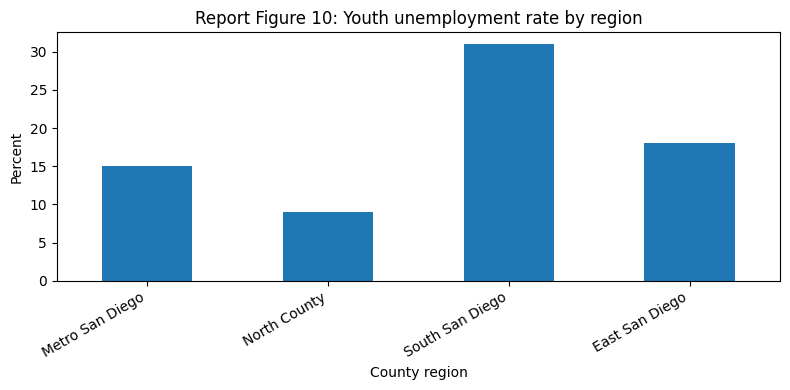

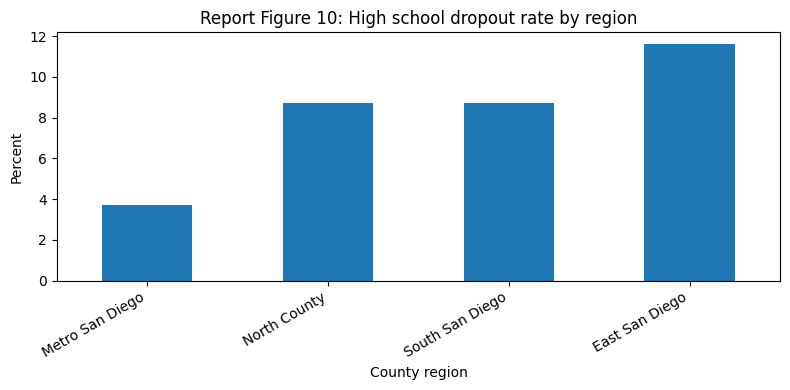

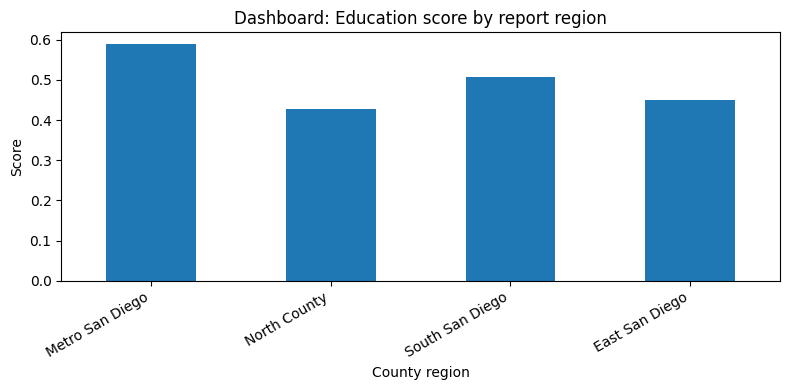

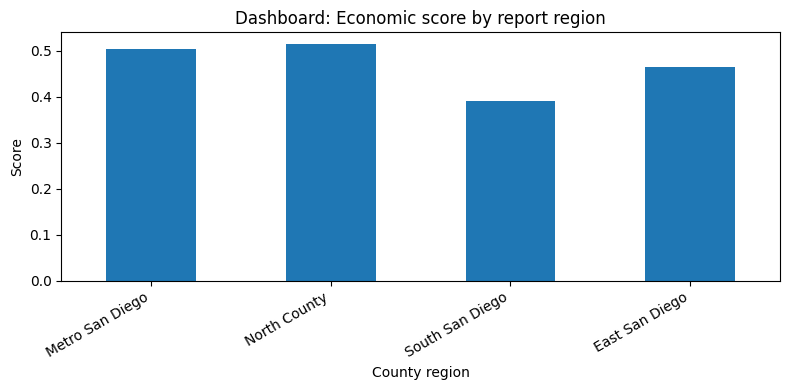

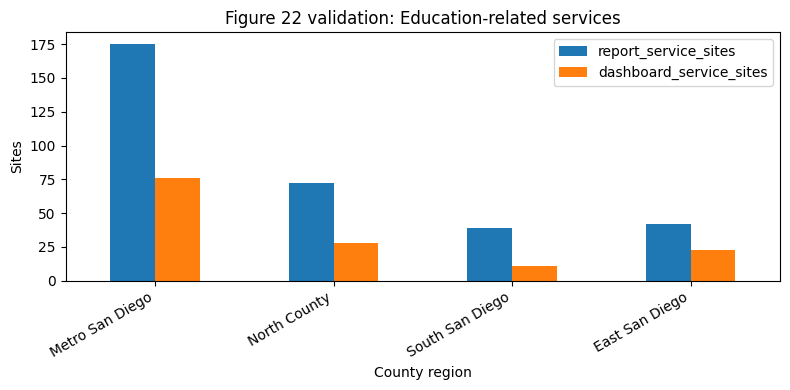

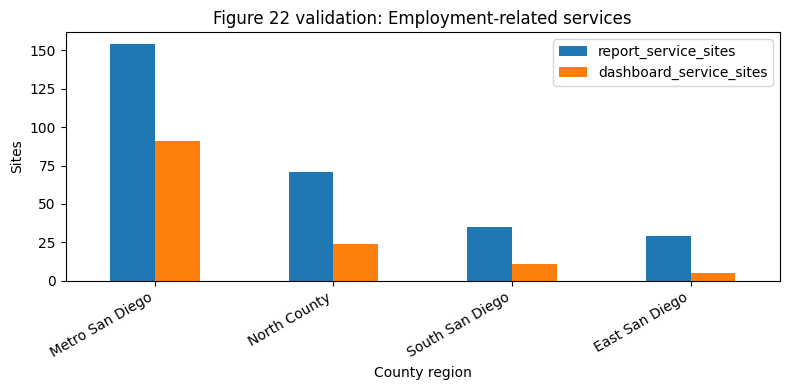

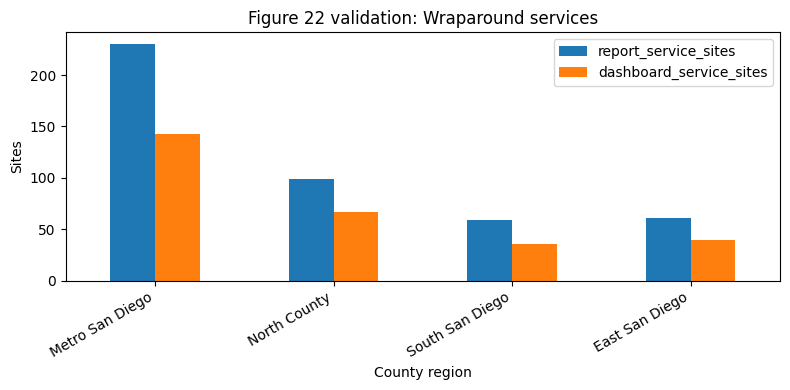

In [13]:
def plot_region_bar(df, value_col, title, ylabel=None):
    if df.empty or value_col not in df.columns:
        print(f'Skipping plot; missing {value_col}')
        return
    plot_df = df.copy()
    plot_df['county_region'] = pd.Categorical(plot_df['county_region'], REGION_ORDER, ordered=True)
    plot_df = plot_df.sort_values('county_region')
    ax = plot_df.plot(kind='bar', x='county_region', y=value_col, legend=False, figsize=(8, 4))
    ax.set_title(title)
    ax.set_xlabel('County region')
    ax.set_ylabel(ylabel or value_col)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

plot_region_bar(fig10, 'youth_unemployment_rate', 'Report Figure 10: Youth unemployment rate by region', 'Percent')
plot_region_bar(fig10, 'high_school_dropout_rate', 'Report Figure 10: High school dropout rate by region', 'Percent')
if 'education_score' in yoi_region.columns:
    plot_region_bar(yoi_region, 'education_score', 'Dashboard: Education score by report region', 'Score')
if 'economic_score' in yoi_region.columns:
    plot_region_bar(yoi_region, 'economic_score', 'Dashboard: Economic score by report region', 'Score')
if not service_validation.empty and service_validation['dashboard_service_sites'].notna().any():
    for domain in service_validation['service_domain'].dropna().unique():
        tmp = service_validation[service_validation['service_domain'] == domain].copy()
        tmp['county_region'] = pd.Categorical(tmp['county_region'], REGION_ORDER, ordered=True)
        tmp = tmp.sort_values('county_region')
        ax = tmp.plot(kind='bar', x='county_region', y=['report_service_sites', 'dashboard_service_sites'], figsize=(8, 4))
        ax.set_title(f'Figure 22 validation: {domain}')
        ax.set_xlabel('County region')
        ax.set_ylabel('Sites')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()


## 10. Generate a validation-report summary

This cell writes a markdown summary you can paste into your validation report. Review the output before using it because exact pass/fail depends on how close your dashboard taxonomy is to the Workforce report taxonomy.

In [14]:
def status_counts(df, status_col='status'):
    if df.empty or status_col not in df.columns:
        return 'no checks run'
    return ', '.join(f'{k}: {v}' for k, v in df[status_col].value_counts(dropna=False).items())

# Pull a few exact report facts for narrative.
fig10_facts = {
    'largest_youth_pop_region': fig10.sort_values('population_ages_14_24', ascending=False).iloc[0]['county_region'],
    'largest_youth_pop_value': int(fig10.sort_values('population_ages_14_24', ascending=False).iloc[0]['population_ages_14_24']),
    'highest_unemployment_region': fig10.sort_values('youth_unemployment_rate', ascending=False).iloc[0]['county_region'],
    'highest_unemployment_value': fig10.sort_values('youth_unemployment_rate', ascending=False).iloc[0]['youth_unemployment_rate'],
    'highest_dropout_region': fig10.sort_values('high_school_dropout_rate', ascending=False).iloc[0]['county_region'],
    'highest_dropout_value': fig10.sort_values('high_school_dropout_rate', ascending=False).iloc[0]['high_school_dropout_rate'],
    'lowest_unemployment_region': fig10.sort_values('youth_unemployment_rate', ascending=True).iloc[0]['county_region'],
    'lowest_unemployment_value': fig10.sort_values('youth_unemployment_rate', ascending=True).iloc[0]['youth_unemployment_rate'],
}
fig2_facts = {
    'largest_not_in_school_region': fig2.sort_values('not_in_school_18_24', ascending=False).iloc[0]['county_region'],
    'largest_not_in_school_value': int(fig2.sort_values('not_in_school_18_24', ascending=False).iloc[0]['not_in_school_18_24']),
    'largest_refugee_region': fig2.sort_values('refugees', ascending=False).iloc[0]['county_region'],
    'largest_refugee_value': int(fig2.sort_values('refugees', ascending=False).iloc[0]['refugees']),
    'largest_homeless_region': fig2.sort_values('youth_experiencing_homelessness', ascending=False).iloc[0]['county_region'],
    'largest_homeless_value': int(fig2.sort_values('youth_experiencing_homelessness', ascending=False).iloc[0]['youth_experiencing_homelessness']),
}

summary = f'''# YOI / Workforce Report Validation Summary

## Report benchmarks used

This validation uses the Workforce report's exact region-level benchmark values from:

- Figure 10, page 15: youth demographic snapshot and education/employment outcomes.
- Figure 2, page 6: youth population characteristics across the four regions.
- Figure 22, page 27: number of sites offering education, employment, and wraparound services by region.
- Figure 7, page 13: limitations, which state that findings should be interpreted directionally rather than exactly.

## Report pattern to validate

From Figure 10, the largest youth population is in **{fig10_facts['largest_youth_pop_region']}** ({fig10_facts['largest_youth_pop_value']:,} youth ages 14-24). The highest youth unemployment rate is in **{fig10_facts['highest_unemployment_region']}** ({fig10_facts['highest_unemployment_value']:.1f}%), while the highest dropout rate is in **{fig10_facts['highest_dropout_region']}** ({fig10_facts['highest_dropout_value']:.1f}%). The lowest unemployment rate is in **{fig10_facts['lowest_unemployment_region']}** ({fig10_facts['lowest_unemployment_value']:.1f}%).

From Figure 2, the largest not-in-school youth count is in **{fig2_facts['largest_not_in_school_region']}** ({fig2_facts['largest_not_in_school_value']:,}); the largest refugee youth count is in **{fig2_facts['largest_refugee_region']}** ({fig2_facts['largest_refugee_value']:,}); and the largest youth homelessness count is in **{fig2_facts['largest_homeless_region']}** ({fig2_facts['largest_homeless_value']:,}).

From Figure 22, Metro San Diego has the highest service-site counts in all three broad domains: education-related services, employment-related services, and wraparound services. South San Diego and East San Diego have substantially smaller service footprints.

## Validation outputs

- Direct metric validation status counts: {status_counts(metric_validation)}
- Service validation status counts: {status_counts(service_validation)}
- Domain trend validation status counts: {status_counts(trend_validation)}

## Files generated

- `data/processed/validation/workforce_report_metric_level_validation.csv`
- `data/processed/validation/workforce_report_service_validation.csv`
- `data/processed/validation/workforce_report_domain_trend_tests.csv`
- `data/processed/validation/workforce_report_region_rank_summary.csv`
- `data/processed/validation/service_category_audit.csv`

## Interpretation guidance

Treat exact numeric differences as a debugging signal, not automatically as an error. The report itself notes limitations from age-range differences, proxy indicators, geographic boundary mismatches, coverage/reporting gaps, timing alignment, and service-data reliability. A strong validation result is therefore: (1) the same four-region geography, (2) the same high/low regional pattern, and (3) reasonable numeric closeness where the dashboard uses the same metric definition and data vintage.
'''

summary_path = OUT_DIR / 'workforce_report_validation_summary.md'
summary_path.write_text(summary, encoding='utf-8')
print('Saved:', summary_path)
print(summary)


Saved: /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/validation/workforce_report_validation_summary.md
# YOI / Workforce Report Validation Summary

## Report benchmarks used

This validation uses the Workforce report's exact region-level benchmark values from:

- Figure 10, page 15: youth demographic snapshot and education/employment outcomes.
- Figure 2, page 6: youth population characteristics across the four regions.
- Figure 22, page 27: number of sites offering education, employment, and wraparound services by region.
- Figure 7, page 13: limitations, which state that findings should be interpreted directionally rather than exactly.

## Report pattern to validate

From Figure 10, the largest youth population is in **Metro San Diego** (180,692 youth ages 14-24). The highest youth unemployment rate is in **South San Diego** (31.0%), while the highest dropout rate is in **East San Diego** (11.6%). The lowest unemployment rate is in **North County** (9.0%).



## 11. Save benchmark tables for transparency

This gives you standalone CSVs containing the exact report values and source references used in the tests.

In [15]:
fig10.to_csv(OUT_DIR / 'report_figure_10_benchmarks.csv', index=False)
fig2.to_csv(OUT_DIR / 'report_figure_2_benchmarks.csv', index=False)
fig22.to_csv(OUT_DIR / 'report_figure_22_service_benchmarks.csv', index=False)
fig22_totals_long.to_csv(OUT_DIR / 'report_figure_22_domain_totals_long.csv', index=False)

print('Saved benchmark files:')
for p in [
    OUT_DIR / 'report_figure_10_benchmarks.csv',
    OUT_DIR / 'report_figure_2_benchmarks.csv',
    OUT_DIR / 'report_figure_22_service_benchmarks.csv',
    OUT_DIR / 'report_figure_22_domain_totals_long.csv',
]:
    print(' -', p)


Saved benchmark files:
 - /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/validation/report_figure_10_benchmarks.csv
 - /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/validation/report_figure_2_benchmarks.csv
 - /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/validation/report_figure_22_service_benchmarks.csv
 - /Users/laurenvo/Documents/Github/youth_opportunity_index/data/processed/validation/report_figure_22_domain_totals_long.csv
